<a href="https://colab.research.google.com/github/Vermont-Complex-Systems/storywrangler/blob/main/notebooks/storywrangler_multi_platforms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Storywrangler multi-platform capabilities

In this notebook, we show how the storywrangler SDK ease the analysis of large scale text corpora.

In [ ]:
!pip install -U storywrangler

In [5]:
# local packages
from storywrangler import Storywrangler

import matplotlib.cm as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [6]:
import storywrangler
storywrangler.__version__

'0.0.21'

In [7]:
client=Storywrangler()

## Twitter and Reddit rank time series

In [8]:
twitter = client.dataset("twitter", "ngrams")
reddit = client.dataset("reddit", "ngrams")

In [16]:
ts1 = twitter.term_series(
    "Trump", entity="United States", lang="en", ngram_size=1, dates="2018-01-01,2023-01-01",
    ).df().set_index("date")['rank']
ts2 = twitter.term_series(
    "Biden", entity="United States", lang="en", ngram_size=1, dates="2018-01-01,2023-01-01"
    ).df().set_index("date")['rank']
ts_df=pd.merge(ts1, ts2, on="date", suffixes=["_Trump", "_Biden"])

In [17]:
tsr1 = reddit.term_series(
    "Trump", lang="en", n=1, dates="2018-01-01,2023-01-01",
    ).df().set_index("date")['rank']
tsr2 = reddit.term_series(
    "Biden", lang="en", n=1, dates="2018-01-01,2023-01-01"
    ).df().set_index("date")['rank']
tsr_df=pd.merge(tsr1, tsr2, on="date", suffixes=["_Trump", "_Biden"])

In [18]:
multi_df=pd.merge(ts_df, tsr_df, on="date", how="left", suffixes=["_twitter", "_reddit"])

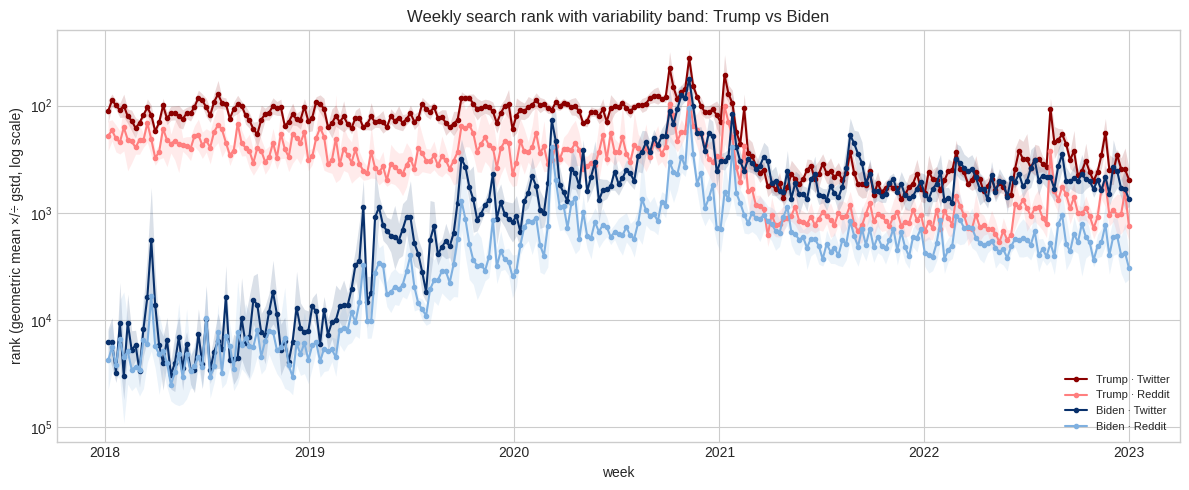

In [19]:
multi_df.index = pd.to_datetime(multi_df.index)
df = multi_df.sort_index()

# geometric mean & geometric std, computed in log space
logdf = np.log(df)
center = np.exp(logdf.resample("W").mean())          # geometric mean
gsd    = np.exp(logdf.resample("W").std())           # geometric std (a ratio, ≥1)
upper  = center * gsd
lower  = center / gsd

styles = {
    "rank_Trump_twitter": dict(color="#8B0000", label="Trump · Twitter"),
    "rank_Trump_reddit":  dict(color="#FF7F7F", label="Trump · Reddit"),
    "rank_Biden_twitter": dict(color="#08306B", label="Biden · Twitter"),
    "rank_Biden_reddit":  dict(color="#7FB0E0", label="Biden · Reddit"),
}

fig, ax = plt.subplots(figsize=(12, 5))
for col, st in styles.items():
    ax.plot(center.index, center[col], marker="o", ms=3,
            color=st["color"], label=st["label"])
    ax.fill_between(center.index, lower[col], upper[col],
                    color=st["color"], alpha=0.15, linewidth=0)

ax.set_yscale("log")
ax.invert_yaxis()
ax.set_ylabel("rank (geometric mean ×/÷ gstd, log scale)")
ax.set_xlabel("week")
ax.set_title("Weekly search rank with variability band: Trump vs Biden")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Adding Wiki to the mix

In [20]:
wiki = client.dataset("wikimedia", "ngrams")

In [21]:
avail=wiki.availability['United States']['1']['daily']
us_timerange=f"{avail['min']},{avail['max']}"
# only english for now
tsw1=wiki.term_series(
    "Trump", entity="United States", ngram_size=1, dates=us_timerange
    ).df().set_index("date")['rank']
tsw2=wiki.term_series(
    "Biden", entity="United States", ngram_size=1, dates=us_timerange
    ).df().set_index("date")['rank']

In [22]:
tsw_df=pd.merge(tsw1, tsw2, on="date", suffixes=["_Trump", "_Biden"])
tsw_df.index = pd.to_datetime(tsw_df.index)

In [23]:
multi_df2=pd.merge(multi_df, tsw_df, on="date", how="outer")

In [24]:
multi_df2=multi_df2.rename(columns={"rank_Trump": "rank_Trump_wiki","rank_Biden": "rank_Biden_wiki"})

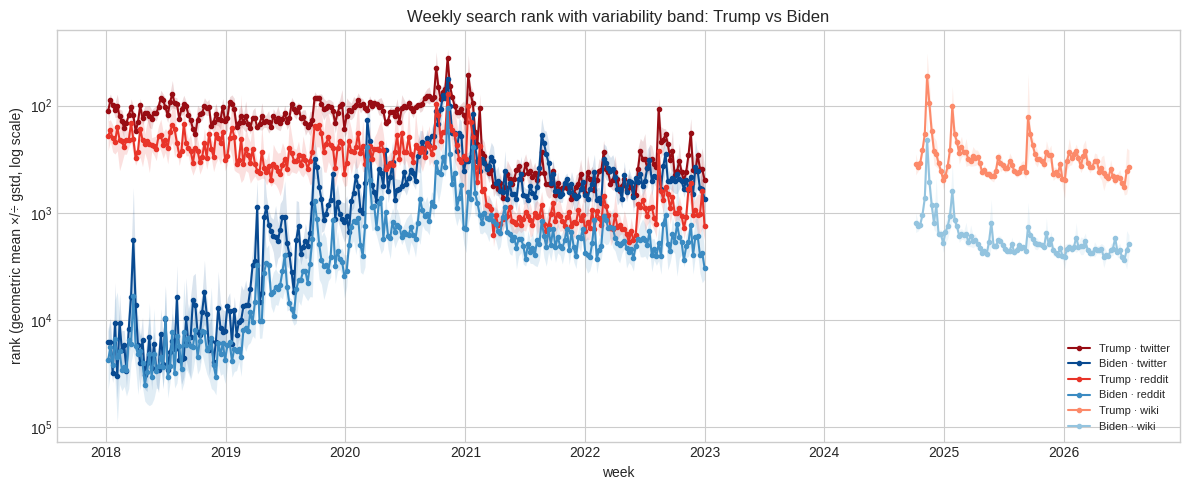

In [25]:
df = multi_df2.sort_index()

# geometric mean & geometric std, computed in log space
logdf = np.log(df)
center = np.exp(logdf.resample("W").mean())          # geometric mean
gsd    = np.exp(logdf.resample("W").std())           # geometric std (a ratio, ≥1)
upper  = center * gsd
lower  = center / gsd

platforms = ["twitter", "reddit", "wiki"]   # dark → light
reds  = cm.Reds( np.linspace(0.9, 0.4, len(platforms)))
blues = cm.Blues(np.linspace(0.9, 0.4, len(platforms)))

styles = {}
for i, plat in enumerate(platforms):
    styles[f"rank_Trump_{plat}"] = dict(color=reds[i],  label=f"Trump · {plat}")
    styles[f"rank_Biden_{plat}"] = dict(color=blues[i], label=f"Biden · {plat}")

fig, ax = plt.subplots(figsize=(12, 5))
for col, st in styles.items():
    ax.plot(center.index, center[col], marker="o", ms=3,
            color=st["color"], label=st["label"])
    ax.fill_between(center.index, lower[col], upper[col],
                    color=st["color"], alpha=0.15, linewidth=0)

ax.set_yscale("log")
ax.invert_yaxis()
ax.set_ylabel("rank (geometric mean ×/÷ gstd, log scale)")
ax.set_xlabel("week")
ax.set_title("Weekly search rank with variability band: Trump vs Biden")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Where next

See our [instrument notebook](https://colab.research.google.com/drive/1cZq56-RbilZgaog39Zx-_qShDL_iML_u?usp=sharing) to see how this multiplatform feature is made even more powerful by our instruments.